In [45]:
import tensorflow as tf 
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np 

In [46]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 25

In [47]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
     shuffle = True,
     image_size = (IMAGE_SIZE, IMAGE_SIZE),
     batch_size = BATCH_SIZE,
)

Found 10000 files belonging to 10 classes.


In [48]:
class_names = dataset.class_names
class_names

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [49]:
len(dataset)

313

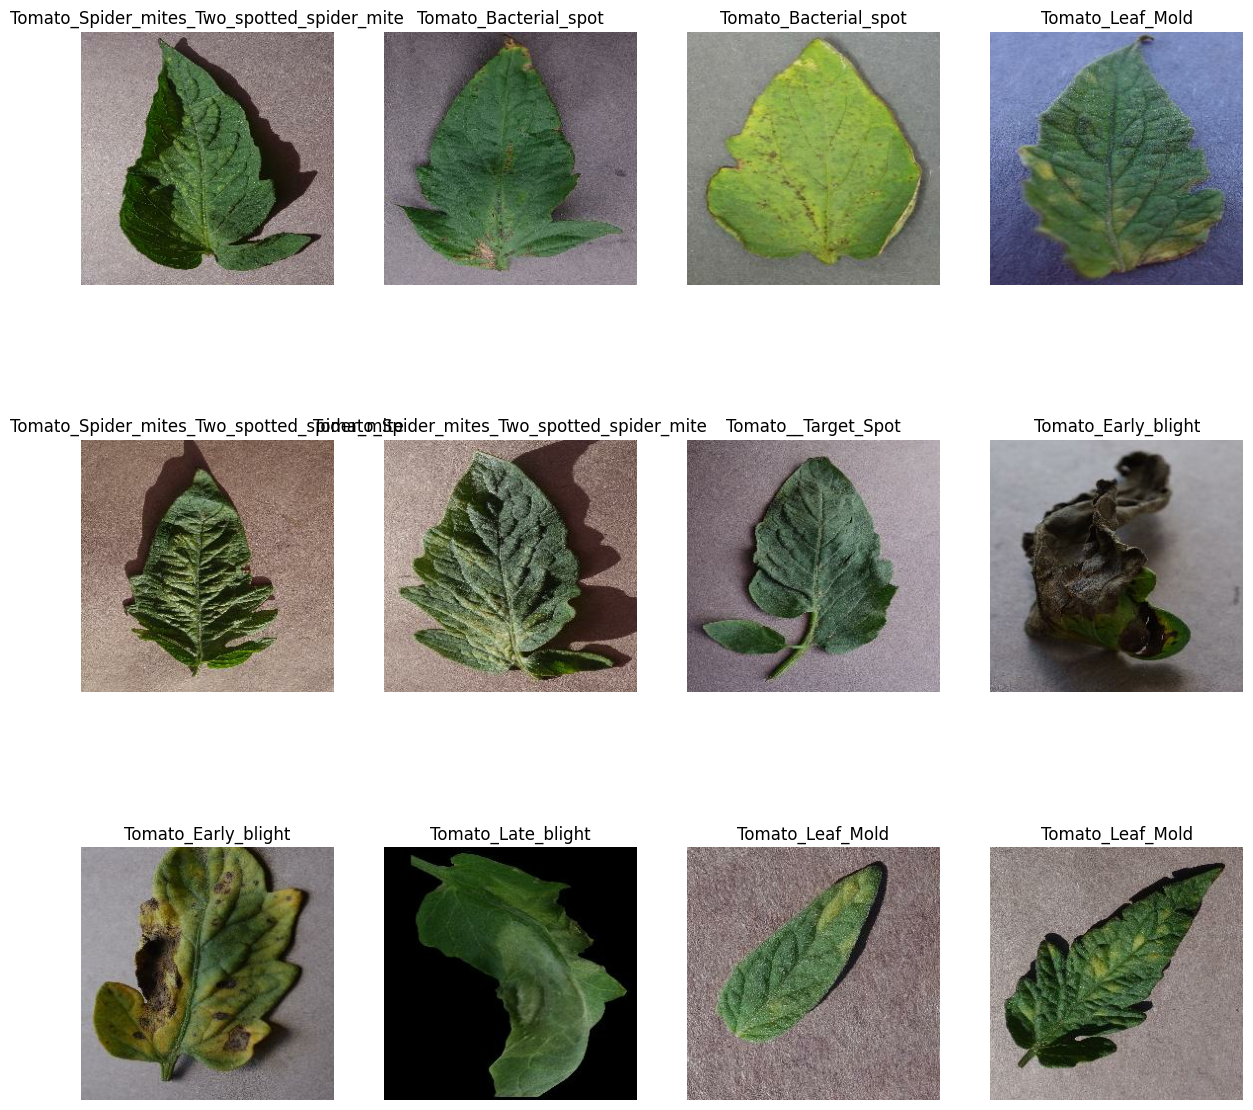

In [50]:
plt.figure(figsize= (15,15))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [51]:
train_size = 0.8
train_ds = dataset.take(int(train_size*len(dataset)))
len(train_ds)

250

In [52]:
test_val_ds = dataset.skip(int(train_size*len(dataset)))
len(test_val_ds)

63

In [53]:
val_size = 0.5
test_size = 0.5 

val_ds = test_val_ds.take(int(val_size*len(test_val_ds)))
test_ds = test_val_ds.take(int(test_size*len(test_val_ds)))

In [54]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=1000):
    ds_size = len(ds)
    if shuffle: 
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)

    train_ds = ds.take(train_size)

    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).take(val_size)

    return train_ds, val_ds, test_ds


In [55]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)
len(train_ds)

250

In [56]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [57]:
## preprocessing pipeline
## When we build our model we'll supply this scale
## becomes useful at the stages past the testing and validating 
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1.0/255)
])

In [58]:
## Data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horisontal_and_vertial"),
    tf.keras.layers.RandomRotation(0.2),
])

In [59]:
n_classes = len(class_names)
input_s = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model  = models.Sequential([
    resize_and_rescale, 
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape = input_s),
    layers.MaxPooling2D((2,2)), 

    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)), 

    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)), 

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)), 

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)), 

    layers.Flatten(), 
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 2304)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 10)               │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,346 (1.06 MB)

 Trainable params: 278,346 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics=['accuracy']
)

In [61]:
history = model.fit(
    train_ds, 
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
   # To see the output
   verbose = 1,
   validation_data = val_ds
)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 152s 585ms/step - accuracy: 0.4006 - loss: 1.5597 - val_accuracy: 0.5605 - val_loss: 1.3196
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 148s 591ms/step - accuracy: 0.6746 - loss: 0.8612 - val_accuracy: 0.7812 - val_loss: 0.6070
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 146s 585ms/step - accuracy: 0.7663 - loss: 0.6396 - val_accuracy: 0.8317 - val_loss: 0.4631
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 143s 570ms/step - accuracy: 0.8305 - loss: 0.4613 - val_accuracy: 0.8669 - val_loss: 0.3841
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 563ms/step - accuracy: 0.8595 - loss: 0.3834 - val_accuracy: 0.8478 - val_loss: 0.4216
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 139s 554ms/step - accuracy: 0.8844 - loss: 0.3326 - val_accuracy: 0.8659 - val_loss: 0.3364
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 139s 555ms/step - accuracy: 0.8932 - loss: 0.3027 - val_accuracy: 0.8508 - val_loss: 0.4087
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 139s 557ms/step - accuracy: 0.9029 -

In [62]:
scores = model.evaluate(test_ds)

31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.9748 - loss: 0.0788


In [64]:
acc = history.history['accuracy']
val_ac = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Accuracy')

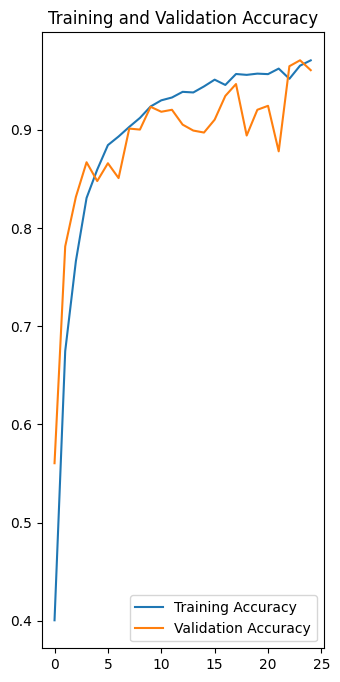

In [65]:
plt.figure(figsize=(8,8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label = 'Training Accuracy')
plt.plot(range(EPOCHS), val_ac, label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')

First image to predict
actual label: Tomato_Bacterial_spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
Predicted label: Tomato_Bacterial_spot
[9.99996305e-01 2.29247746e-07 3.47718264e-06 1.08446806e-14
 5.98275665e-11 1.16122658e-08 3.24786198e-09 1.26973744e-18
 2.39552166e-13 2.34668699e-15]


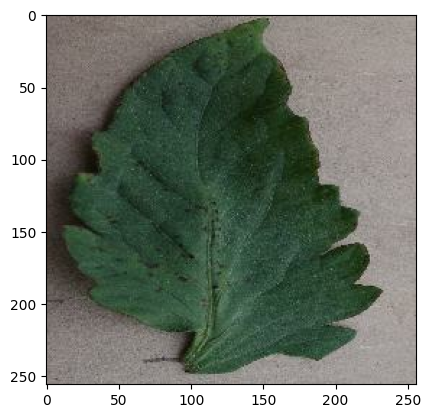

In [66]:
for images_batch, label_batch in test_ds.take(1):
    first_image = (images_batch[0].numpy().astype('uint8'))
    first_label = label_batch[0].numpy()

    print("First image to predict")
    plt.imshow(first_image)
    print("actual label:", class_names[first_label])

    # This is the prediction for the whole of the first batch

    batch_prediction = model.predict(images_batch)
    print("Predicted label:", class_names[np.argmax(batch_prediction[0])])

    # To obtain the prediction of an instance of the batch 
    print(batch_prediction[0])

In [67]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # Create Batch

    predictions = model.predict(img_array)
    
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


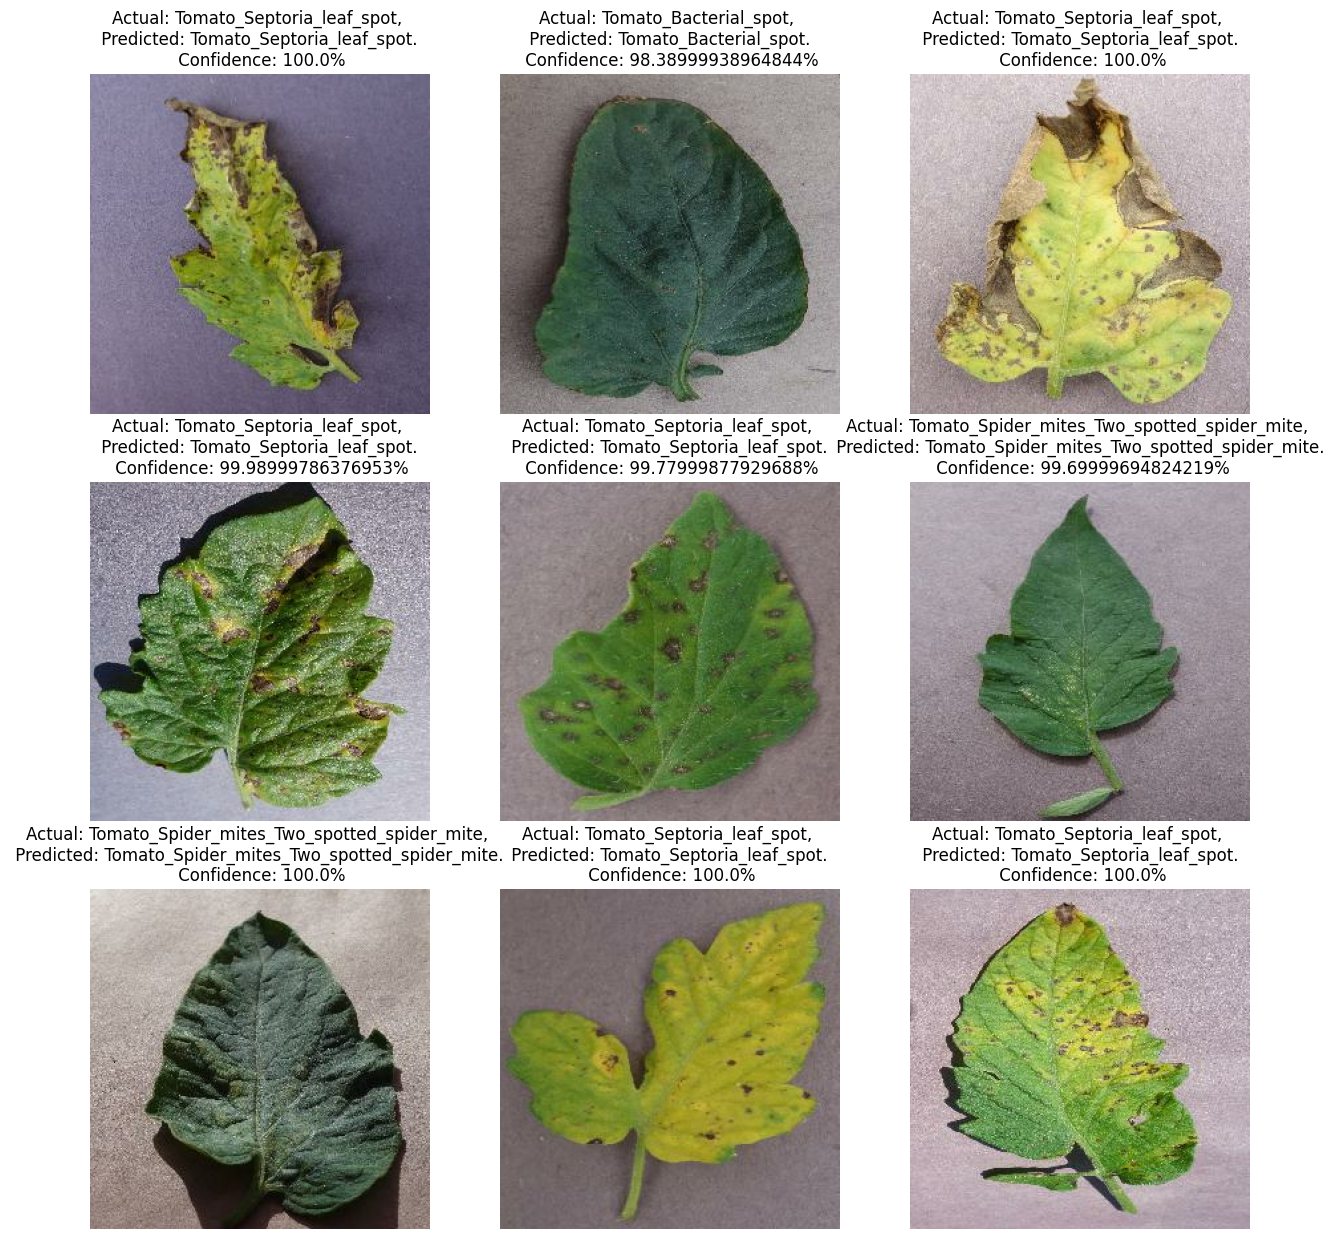

In [68]:
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax= plt.subplot(3 , 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}. \n Confidence: {confidence}%")
        plt.axis("off")

In [70]:
model.save("../Models/1.keras")